## Tratamento de Dados

#### Importando bibliotecas úteis

In [3]:
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

### Dados Problemáticos

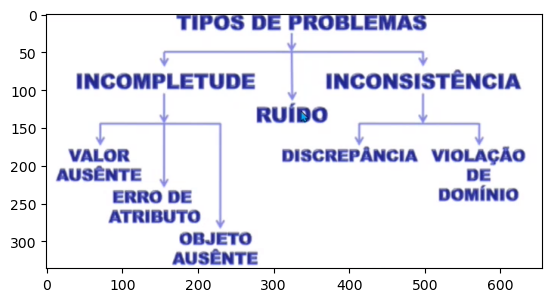

In [5]:
img = np.asarray(Image.open('TiposProblemasDados.png'))
plt.imshow(img)
print('')

Para resolver esses problemas, notamos ter 2 soluções principais:
- Remover dados/amostras
- Imputar valores

### Removendo Valores
Utilizaremos técnicas estatísticas para identificar valores anormais (i.e. raros ou errados); esses dados poderão ser removidos ou selecionados para correção (veremos imputação mais adiante)

#### IQR (interquartil-range)

Podemos usar as medidas de dispersão e distribuição para avaliar e encontrar amostras que estão muito distantes do esperado. Uma dar formas é o intervalo interquartil
<br>$IQR = (Q3 - Q1)$
<br>
O interquartil separa metade dos dados que estão na parte central, i.e. de 25% à 75%. Podemos pensar que valores que se afastam em uma proporção dessa amplitude são raros ou ruído

In [10]:
vendas = pd.read_csv("vendasRuido.csv", header=None) #valores ? indicam valores faltantes na nossa base
vendas.columns=['hora','prod1','prod2']
vendas[['prod1','prod2']].describe()

,prod1,prod2
count,216.000000,216.000000
mean,25.486111,22.828704
std,5.939994,5.043376
min,10.000000,2.000000
25%,22.000000,20.000000
50%,25.000000,23.000000
75%,28.000000,26.000000
max,80.000000,55.000000


Por exemplo, vemos que para o produto 1, temos entre 10 e 80 vendas por hora; mas em 50% das horas amostradas, temos entre 22 e 28 vendas. É intuitivo pensar que se na metade das horas as vendas oscilam em 6 pontos (nosso IQR), valores que se distanciem em 6 pontos do Q1 e do Q3 sejam bem mais raros. Em aplicações reais tendemos a ser ainda mais permissivos na nossa margem, **multiplicamos o IQR por 1.5** e adicionamos ou subtraímos de Q3 e Q1 (respectivamente) para definir a nossa região de dados 'comuns'. Esse valor é tão usado que é pradrão em um plot estatístico, o **boxplot**

'> (Q3 + IQR*1.5) - Outlier

'< (Q1 - IQR*1.5) - Outlier

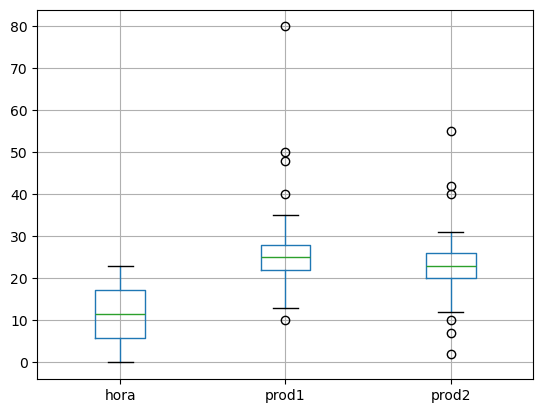

In [12]:
vendas.boxplot()
plt.show()

In [13]:
vendas

,hora,prod1,prod2
0,0,24,21
1,1,30,27
2,2,26,24
3,3,24,21
4,4,27,22
...,...,...,...
211,19,26,25
212,20,26,25
213,21,23,22
214,22,21,17


In [14]:
#Calculando IQR e margem 'válida'
IQR = vendas[['prod1','prod2']].quantile(0.75) - vendas[['prod1','prod2']].quantile(0.25)
margemMin = vendas[['prod1','prod2']].quantile(0.25) - IQR*1.5
margemMax = vendas[['prod1','prod2']].quantile(0.75) + IQR*1.5

#Filtrando valores anormais/outliers
idx=[]
for col in ['prod1','prod2']:
    filtered = vendas[col][(vendas[col] < margemMin[col]) | (vendas[col] > margemMax[col])]
    idx.extend(filtered.index)
vendas.iloc[idx]

,hora,prod1,prod2
40,16,50,21
65,17,10,22
78,6,80,24
83,11,48,24
120,0,40,25
38,14,26,10
50,2,26,42
67,19,25,2
76,4,24,55
81,9,26,7


In [15]:
#vendas.info() #nossa base original possui 216 amostras
vendas.iloc[idx].info() #dessas 216, 11 possuem algum tipo de anormalidade ~ 5%

<class 'pandas.core.frame.DataFrame'>
Index: 11 entries, 40 to 118
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   hora    11 non-null     int64
 1   prod1   11 non-null     int64
 2   prod2   11 non-null     int64
dtypes: int64(3)
memory usage: 352.0 bytes


#### Alta distância para a média em termos de desvios padrões

Ainda sob essa perspectiva de usar alguma medida de amplitude para medir valores anormais. Podemos utilizar o desvio padrão. Sabemos que em amostras simétricas temos 68% das amostras dentro de 1 desvio padrão da média, e quando aumentamos essa margem para 3 desvios padrões temos cerca de 99.7%. Iremos filtrar fora todas as amostras que estão a 3 desvios padrões da média, para mais ou para menos

In [18]:
#Calculando IQR e margem 'válida'
deviation = vendas[['prod1','prod2']].std()
margemMin = vendas[['prod1','prod2']].mean() - 3*deviation
margemMax = vendas[['prod1','prod2']].mean() + 3*deviation

#Filtrando valores anormais/outliers
idx=[]
for col in ['prod1','prod2']:
    filtered = vendas[col][(vendas[col] < margemMin[col]) | (vendas[col] > margemMax[col])]
    idx.extend(filtered.index)
vendas.iloc[idx]

,hora,prod1,prod2
40,16,50,21
78,6,80,24
83,11,48,24
50,2,26,42
67,19,25,2
76,4,24,55
81,9,26,7
118,22,21,40


In [19]:
#vendas.info() #nossa base original possui 216 amostras
vendas.iloc[idx].info() #dessas 216, 8 estão muito fora da média ~ 3,7%

<class 'pandas.core.frame.DataFrame'>
Index: 8 entries, 40 to 118
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   hora    8 non-null      int64
 1   prod1   8 non-null      int64
 2   prod2   8 non-null      int64
dtypes: int64(3)
memory usage: 256.0 bytes


**Dicussões e reflexões:**
- Notamos que cada abordagem se comporta de uma maneira diferente. A IQR se preocupa com a amplitude, independente de assimetria ou desvio padrão; enquanto que a baseada em 3 desvios padrões tem uma interpretação muito boa para distribuições normais
- Sempre serão usados esse limiares (i.e. 3 desvios e 1.5 vezes o IQR)?

### Imputando valores

Podemos imputar valores tanto para corrigir valores anômalos, quanto para imputar valores que não estavam presentes na base original

In [23]:
vendas = pd.read_csv("vendasMissing.csv", header=None, na_values='?') #valores ? indicam valores faltantes na nossa base
vendas.columns=['hora','prod1','prod2']

In [24]:
len(vendas)

216

In [25]:
vendas[12:36] #Pandas marcou valores faltantes como NaN, especificamente pd.NA

,hora,prod1,prod2
12,12,27.0,24.0
13,13,21.0,19.0
14,14,NaN,25.0
15,15,25.0,22.0
16,16,21.0,20.0
17,17,25.0,22.0
18,18,20.0,18.0
19,19,24.0,21.0
20,20,18.0,17.0
21,21,22.0,20.0


In [26]:
vendas[vendas['prod1'].isnull() | vendas['prod2'].isnull()].index #encontrando os índices onde tempos valores faltantes

Index([  4,   6,   9,  14,  24,  28,  38,  40,  50,  52,  65,  67,  76,  78,
        80,  81,  83,  99, 108, 110, 117, 118, 120, 123, 137, 138, 140],
      dtype='int64')

Como temos uma série, é plausível assumir que o valor não irá mudar muito em relação à valores próximos; vimos que uma abordagem possível é imputar a **média** dos valores anterior e posterior

Mas e se não tivermos uma sequência de amostras, em cenários onde cada amostra representa algo indepentente, e.g. população, Iris, não é viável escolher a amostra anterior e posterior, muitas vezes não haverá relação direta entre amostras em sequência

Dito isso, podemos usar a população de amostras a nosso favor

#### Entendendo nossos dados e imputando valores centrais

In [30]:
pessoas = pd.read_csv('pessoasMissing.csv',na_values='?') #valores ? indicam valores faltantes na nossa base
pessoas

,alt,peso
0,1.713154,80.532690
1,1.889350,83.094487
2,NaN,75.976252
3,1.516484,70.051837
4,1.951341,NaN
5,2.158034,93.027127
6,1.290006,64.652652
7,1.441092,74.031698
8,2.064628,91.644868
9,1.673236,75.987265


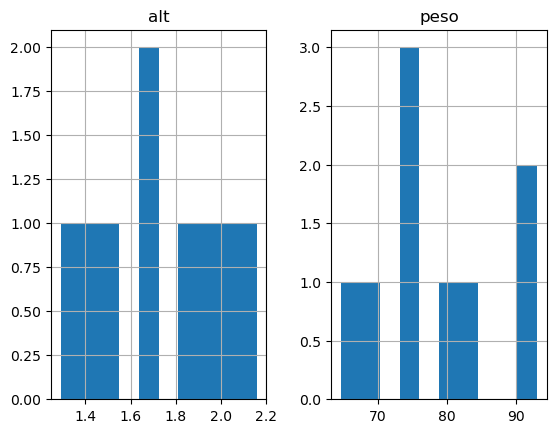

In [31]:
pessoas.hist()#plotando histograma das duas variáveis
plt.show()

In [32]:
pessoas.describe().loc[['mean','50%']] #Outra forma de ver eventuais caldas,
                                            #uma vez que já notamos que temos apenas um 'pico'

,alt,peso
mean,1.744147,78.777653
50%,1.713154,75.987265


Nossa base de dados é bem simétrica, podemos substituir os valores faltantes pela média da coluna, sem muito risco de imputar um valor extraordinário

In [34]:
pessoasCompleto = pessoas.fillna(pessoas.mean())
pessoasCompleto

,alt,peso
0,1.713154,80.532690
1,1.889350,83.094487
2,1.744147,75.976252
3,1.516484,70.051837
4,1.951341,78.777653
5,2.158034,93.027127
6,1.290006,64.652652
7,1.441092,74.031698
8,2.064628,91.644868
9,1.673236,75.987265


Mas podemos ter situações diferentes

In [36]:
pessoas2 = pd.read_csv('pessoas2Missing.csv', na_values='?')
pessoas2.head(10)

,alt,peso
0,1.889350,83.094487
1,1.673236,75.987265
2,1.134155,29.542677
3,1.441092,74.031698
4,1.251056,30.871309
5,1.002921,23.681984
6,2.158034,93.027127
7,NaN,75.976252
8,0.890140,NaN
9,0.939763,17.860545


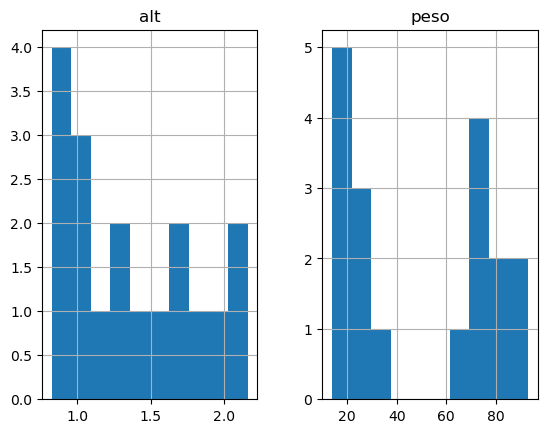

In [37]:
pessoas2.hist()
plt.show()

In [38]:
pessoas2.describe().loc[['mean','50%']] #a média ainda é próxima da mediana, indicando uma pequena calda ou simetria,
                                            #mas notem que ambas são péssimas medidas de centralidade das amostras nesse caso

,alt,peso
mean,1.374204,50.080269
50%,1.270531,47.761980


Não temos mais algo simétrico, com um centro bem definido; imputaremos o peso como 70, ou como 20? A média de 50 não possui nenhuma evidência...
A solução é imputar valores diferentes para amostras diferentes

Para o peso notamos dois grupos óbvios, com mais ou menos de 50Kg, poderíamos usar essa separação para imputar na média ou mediana;

In [41]:
pessoas2_50mais = pessoas2[pessoas2['peso'] > 50] # sabemos que não há peso igual a 50, é um limiar bem amplo
pessoas2_50menos = pessoas2[pessoas2['peso'] < 50] # sabemos que não há peso igual a 50, é um limiar bem amplo

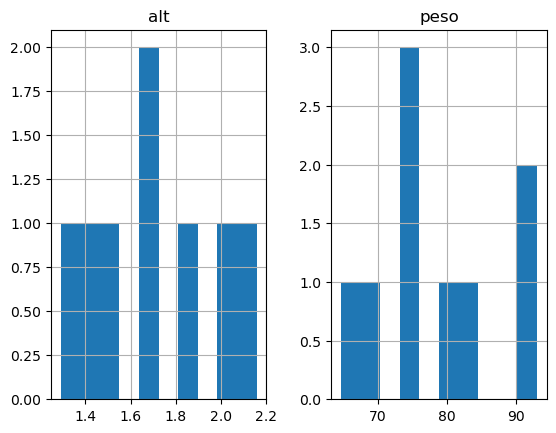

In [42]:
pessoas2_50mais.hist()
plt.show()

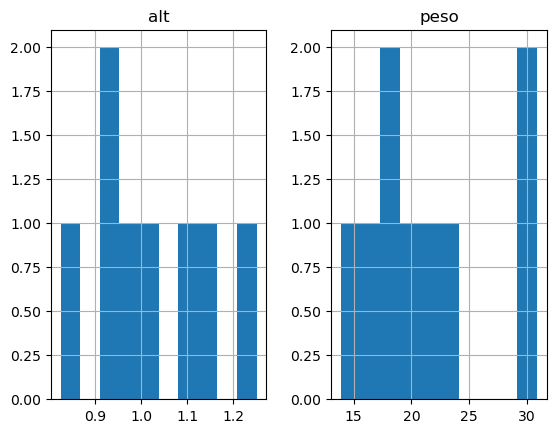

In [43]:
pessoas2_50menos.hist()
plt.show()

In [44]:
pessoas2_50maisCompleto = pd.Series(dtype=float)
pessoas2_50menosCompleto = pd.Series(dtype=float)
pessoas2Completo = pd.Series(dtype=float)
pessoas2_50maisCompleto['peso'] = pessoas2[pessoas2['peso'] > 50]['peso'].fillna(pessoas2[pessoas2['peso'] > 50]['peso'].mean())
pessoas2_50menosCompleto['peso'] = pessoas2[pessoas2['peso'] < 50]['peso'].fillna(pessoas2[pessoas2['peso'] < 50]['peso'].mean())

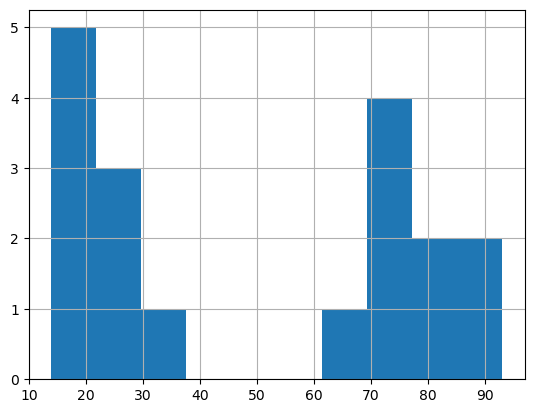

In [45]:
pessoas2Completo['peso'] = pd.concat([pessoas2_50maisCompleto['peso'],pessoas2_50menosCompleto['peso']],axis=0)
pessoas2Completo['peso'].hist()
plt.show()

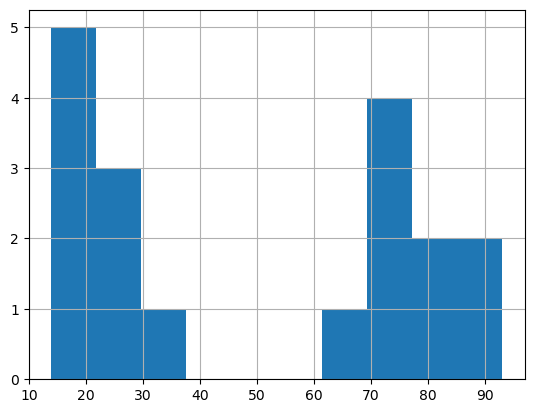

In [46]:
pessoas2['peso'].hist()
plt.show()

Comparando os 2 histogramas (antes e depois da imputação) não vemos grandes alterações no formato, isso é um bom sinal

Quanto à altura não conseguimos encontrar um corte evidente, precisamos de uma forma mais objetiva para imputar valores; será que podemos utilizar a decrição nas outras variáveis para imputar valores? e.g. amostras com pesos parecidos devem ter alturas parecidas; veremos o conceito de imputação por vizinhança

#### Imputando por vizinhança
Quando imputamos por vizinhança, nossa suposição é que amostras similares têm características similares
<br>Caso nossa base seja rotulada, definir essas vizinhanças pode ser bem simples

In [50]:
pessoas2b = pd.read_csv('pessoas2bMissing.csv', na_values='?')
pessoas2b

,alt,peso,Faixa Etária
0,0.890140,NaN,Criança
1,2.158034,93.027127,Adulto
2,NaN,16.430882,Criança
3,1.290006,64.652652,Adulto
4,1.951341,NaN,Adulto
5,1.002921,23.681984,Criança
6,1.251056,30.871309,Criança
7,1.441092,74.031698,Adulto
8,1.082627,22.247003,Criança
9,1.713154,80.532690,Adulto


Nesse caso sabemos que a base possui adultos e crianças, o que justifica a mudança súbita em peso e a distribuição anormal de altura

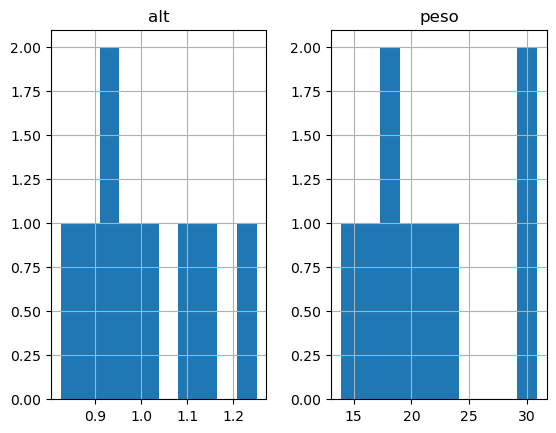

In [52]:
pessoas2b[pessoas2b['Faixa Etária']=='Criança'][['alt','peso']].hist()
plt.show()

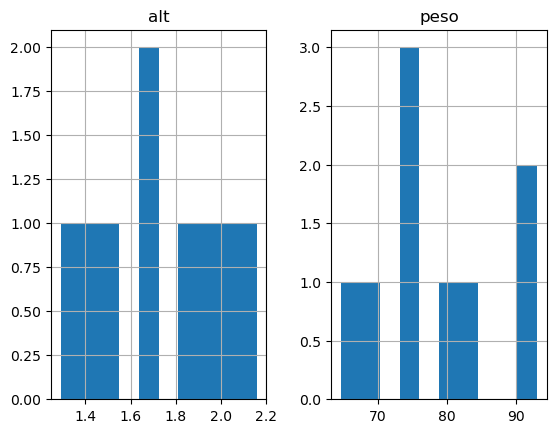

In [53]:
pessoas2b[pessoas2b['Faixa Etária']=='Adulto'][['alt','peso']].hist()
plt.show()

Vemos que podemos imputar a média da classe ao invés da média global

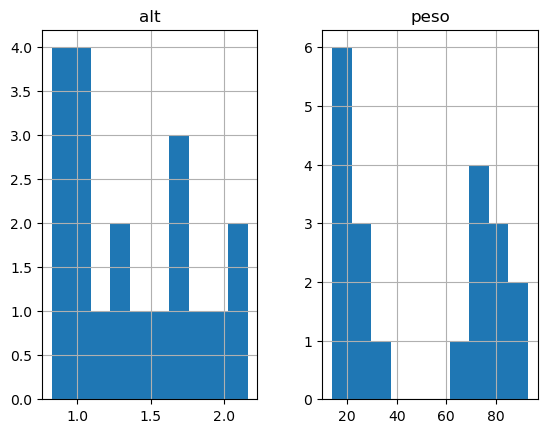

In [55]:
pessoas2bAdultosM = pessoas2b[pessoas2b['Faixa Etária']=='Adulto'][['alt','peso']].mean()
pessoas2bCriancaM = pessoas2b[pessoas2b['Faixa Etária']=='Criança'][['alt','peso']].mean()
pessoas2bCompleto = pessoas2b.copy()
pessoas2bCompleto[pessoas2bCompleto['Faixa Etária']=='Adulto'] = pessoas2bCompleto[pessoas2bCompleto['Faixa Etária']=='Adulto'].fillna(pessoas2bAdultosM)
pessoas2bCompleto[pessoas2bCompleto['Faixa Etária']=='Criança'] = pessoas2bCompleto[pessoas2bCompleto['Faixa Etária']=='Criança'].fillna(pessoas2bCriancaM)
#O for abaixo faz o mesmo procedimento acima
# pessoas2bCompleto = pessoas2b.copy()
# for fe in ['Adulto','Criança']:
#     media = pessoas2bAdultosM = pessoas2b[pessoas2b['Faixa Etária']==fe][['alt','peso']].mean()
#     pessoas2bCompleto[pessoas2bCompleto['Faixa Etária']==fe] = pessoas2bCompleto[pessoas2bCompleto['Faixa Etária']==fe].fillna(media)
pessoas2bCompleto.hist()
plt.show()

Caso não tenhamos as classes, ainda assim podemos utilizar o(s) atributo(s) disponíveis para medir essas distâncias
<br> Faremos um exemplo simples em uma base com apenas 2 atributos

In [57]:
pessoas2 = pd.read_csv('pessoas2Missing.csv', na_values='?')
pessoas2.head(10)

,alt,peso
0,1.889350,83.094487
1,1.673236,75.987265
2,1.134155,29.542677
3,1.441092,74.031698
4,1.251056,30.871309
5,1.002921,23.681984
6,2.158034,93.027127
7,NaN,75.976252
8,0.890140,NaN
9,0.939763,17.860545


In [58]:
#encontrando valores faltantes
pessoas2[(pd.isna(pessoas2['alt'])) | (pd.isna(pessoas2['peso'])) ]
amostrasFaltantes = pessoas2[(pd.isna(pessoas2['alt'])) | (pd.isna(pessoas2['peso'])) ].index
#amostrasFaltantes
pessoas2.iloc[amostrasFaltantes]

,alt,peso
7,NaN,75.976252
8,0.890140,NaN
14,1.951341,NaN
18,NaN,16.430882


Vamos encontrar as amostras vizinhas da amostra 7. Não podemos usar a informação da altura, já que ela é indefinida para a amostra 7. Iremos ver a disposição das amostras em relação ao peso e vamos tentar encontrar as amostras mais parecidas/próximas da amostra 7 (em vermelho)

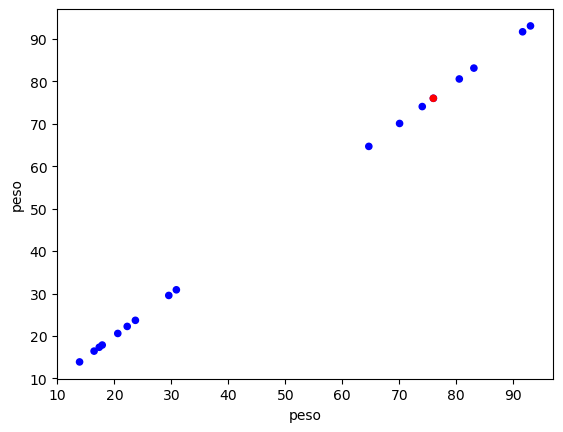

In [60]:
cores=['b' if x != 7 else 'r' for x in pessoas2.index] #usaremos a cor azul para todos exceto o 7 (vermelho)
pessoas2.plot.scatter('peso','peso', color=cores)
plt.show()

In [61]:
pessoas2['peso']

0     83.094487
1     75.987265
2     29.542677
3     74.031698
4     30.871309
5     23.681984
6     93.027127
7     75.976252
8           NaN
9     17.860545
10    22.247003
11    20.590786
12    80.532690
13    64.652652
14          NaN
15    91.644868
16    13.884593
17    17.336188
18    16.430882
19    70.051837
Name: peso, dtype: float64

In [63]:
from scipy.spatial.distance import pdist
from scipy.spatial.distance import squareform
Y = pdist([[x] for x in pessoas2['peso'].values], 'euclidean')
dist_matrix = squareform(Y)
dm = pd.DataFrame(dist_matrix)
dm
dm[7].sort_values()
#dm[7].sort_values().index[1]
#pessoas2.iloc[1]['peso']

7      0.000000
1      0.011013
3      1.944553
12     4.556438
19     5.924415
0      7.118235
13    11.323600
15    15.668617
6     17.050875
4     45.104943
2     46.433575
5     52.294267
10    53.729249
11    55.385466
9     58.115707
17    58.640063
18    59.545370
16    62.091659
8           NaN
14          NaN
Name: 7, dtype: float64

In [79]:
#Calcularemos a média da ALTURA dos vizinhos de 7 e imputaremos como a altura dele
qtdVizinhos = 3 #mude essa variável para udar a vizinhança, o gráfico e o valor imputado será alterado de acordo

alt = 0
vizinhos=[]
for i in range(1,qtdVizinhos+1):
    idxVizinho = dm[7].sort_values().index[i]
    vizinhos.append(idxVizinho)
    altVizinho = pessoas2.iloc[idxVizinho]['alt']
    print(altVizinho)
    alt = alt+altVizinho
alt = alt/qtdVizinhos
pessoas2.loc[7, 'alt'] = alt

print(alt)

1.673236330068345
1.441092327600191
1.7131535992242517
1.609160752297596


In [67]:
pessoas2.loc[[7,1,3,12,16]]

,alt,peso
7,1.609161,75.976252
1,1.673236,75.987265
3,1.441092,74.031698
12,1.713154,80.532690
16,0.824773,13.884593


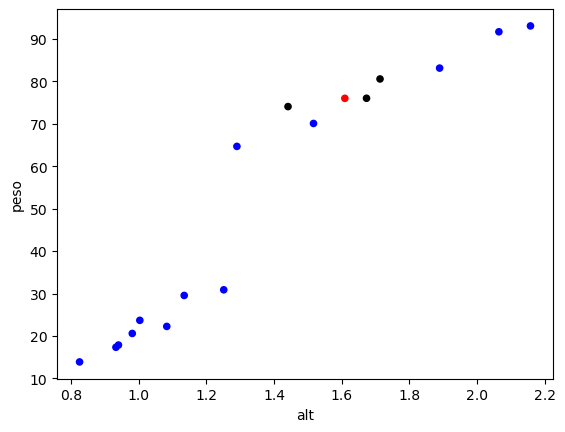

In [69]:
#Visualizando
cores=[]
for idx in pessoas2.index:
    if idx == 7: #alvo vermelho
        cores.append('r')
    elif vizinhos.__contains__(idx): #vizinhos pretos
        cores.append('k')
    else: #outros azuis
        cores.append('b') 
        
pessoas2.plot.scatter('alt','peso', color=cores)
plt.show()

### Rodando com apenas 2 vizinhos notamos algo inusitado

1.673236330068345
1.441092327600191


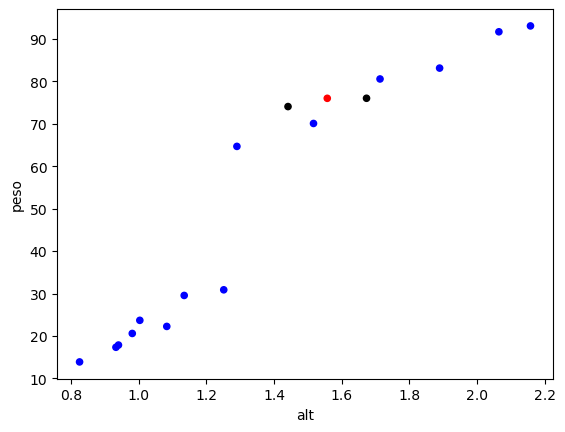

In [75]:
#Calcularemos a média da ALTURA dos vizinhos de 7 e imputaremos como a altura dele
qtdVizinhos = 2  

alt = 0
vizinhos=[]
for i in range(1,qtdVizinhos+1):
    idxVizinho = dm[7].sort_values().index[i]
    vizinhos.append(idxVizinho)
    altVizinho = pessoas2.iloc[idxVizinho]['alt']
    print(altVizinho)
    alt = alt+altVizinho
alt = alt/qtdVizinhos
pessoas2.loc[7, 'alt'] = alt

#Visualizando
cores=[]
for idx in pessoas2.index:
    if idx == 7: #alvo vermelho
        cores.append('r')
    elif vizinhos.__contains__(idx): #vizinhos pretos
        cores.append('k')
    else: #outros azuis
        cores.append('b') 

x = pessoas2.plot.scatter('alt','peso', color=cores)
plt.show()

O ponto azul (1.5,70) parece mais próximo que o vizinho da esquerda (1.45,75). Por que isso acontece? O nosso gráfico está distorcido a altura varia entre 0.8 e 2.2 enquanto que o peso varia entre 10 e 90. Um gráfico em escala seria:

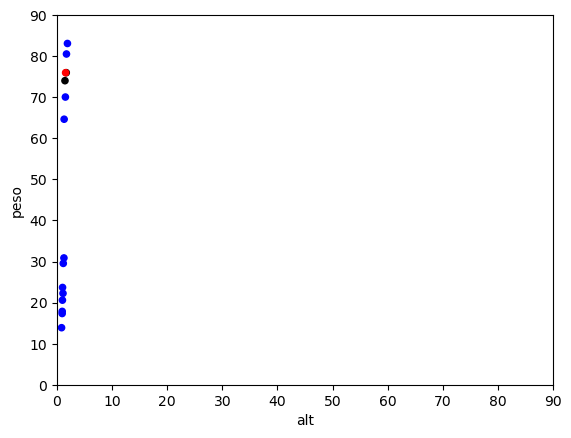

In [73]:
pessoas2.plot.scatter('alt','peso', color=cores,xlim=(0,90),ylim=(0,90))
plt.show()

Agora fica evidente que a distância na vertical (cerca de 8 pontos/kg) era maior que na horizontal (cerca de 0.2 pontos/m)
<br>Alguns algoritmos e abordagens serão sensíveis a essa diferença de escala, iremos aprender a corrigir isso na próxima aula!

**Discussões:**
- Podemos utilizar o conceito de agrupamento visto na aula anterior para medir essas similaridades?
- Medimos distâncias para encontrar os vizinhos das nossas amostras, o processo seria o mesmo caso tivéssemos mais atributos?

**Preocupações:**
- Os dados imputados não são um chute, devem ser uma aproximação do valor esperado
- Elas devem alterar a distribuição dos dados o mínimo possível, evitando 'novidades'
- Dados imputados têm menos embasamento na realidade, afinal os dados originais foram coletados do 'mundo real', são evidência; já os dados imputados foram colocados artificialmente; dito isso, ambos serão tratados da mesma forma pelos nossos algoritmos